In [6]:
import pandas as pd
import numpy as np
#Upload Data
from google.colab import files
uploaded = files.upload()


Saving PlayerStatistics_2020-2025.csv to PlayerStatistics_2020-2025.csv
Saving Games_2020-2025.csv to Games_2020-2025.csv


In [7]:
#Task 1: Load Data
games = pd.read_csv("Games_2020-2025.csv")
player_stats = pd.read_csv("PlayerStatistics_2020-2025.csv")
games.head()
player_stats.head()

/tmp/ipython-input-2926928809.py:3: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  player_stats = pd.read_csv("PlayerStatistics_2020-2025.csv")


,firstName,lastName,personId,gameId,gameDate,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,...,threePointersPercentage,freeThrowsAttempted,freeThrowsMade,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints
0,Chris,Paul,101108,22500164,2025-11-03T22:30:00Z,LA,Clippers,Miami,Heat,NaN,...,0.250,0.0,0.0,0.0,3.0,1.0,4.0,2.0,2.0,6.0
1,Norman,Powell,1626181,22500164,2025-11-03T22:30:00Z,Miami,Heat,LA,Clippers,NaN,...,0.667,7.0,7.0,1.0,2.0,0.0,2.0,2.0,5.0,4.0
2,Kris,Dunn,1627739,22500164,2025-11-03T22:30:00Z,LA,Clippers,Miami,Heat,NaN,...,1.000,0.0,0.0,0.0,1.0,2.0,3.0,3.0,1.0,-2.0
3,Ivica,Zubac,1627826,22500164,2025-11-03T22:30:00Z,LA,Clippers,Miami,Heat,NaN,...,0.000,2.0,1.0,0.5,13.0,5.0,18.0,5.0,3.0,-6.0
4,Derrick,Jones Jr.,1627884,22500164,2025-11-03T22:30:00Z,LA,Clippers,Miami,Heat,NaN,...,0.500,2.0,1.0,0.5,3.0,0.0,3.0,2.0,1.0,3.0


In [8]:
#Task 2: For both dataset, only keep information for games played since 2023-01-01
games = games[games['gameDate'] >= '2023-01-01']
player_stats = player_stats[player_stats['gameDate'] >= '2023-01-01']

In [9]:
#Task 3: For the dataframe with player statistics information, figure out for each column, how many percentage of values are missing
player_stats_missing = player_stats.isnull().sum() / len(player_stats) * 100
print(player_stats_missing)

firstName                   0.000000
lastName                    0.000000
personId                    0.000000
gameId                      0.000000
gameDate                    0.000000
playerteamCity              0.000000
playerteamName              0.000000
opponentteamCity            0.000000
opponentteamName            0.000000
gameType                    4.908037
gameLabel                  81.039396
gameSubLabel               95.200566
seriesGameNumber           57.992747
win                         0.000000
home                        0.000000
numMinutes                 19.703884
points                      0.000000
assists                     0.000000
blocks                      0.000000
steals                      0.000000
fieldGoalsAttempted         0.000000
fieldGoalsMade              0.000000
fieldGoalsPercentage        0.000000
threePointersAttempted      0.000000
threePointersMade           0.000000
threePointersPercentage     0.000000
freeThrowsAttempted         0.000000
f

In [10]:
#Task 4: Based on your results of Task 3, drop columns that has 15% or over missing values
player_stats = player_stats.drop(["gameLabel", "gameSubLabel", "seriesGameNumber", "numMinutes"], axis=1)

In [11]:
#Task 5: For the dataset with game information, figure out for each column, how many percent of values are missing
games_missing = games.isnull().sum() / len(games) * 100
print(games_missing)

gameId               0.000000
gameDate             0.000000
hometeamCity         0.000000
hometeamName         0.000000
hometeamId           0.000000
awayteamCity         0.000000
awayteamName         0.000000
awayteamId           0.000000
homeScore            0.000000
awayScore            0.000000
winner               0.000000
gameType             4.332616
attendance           0.457481
arenaId              4.682454
gameLabel           83.315393
gameSubLabel        95.371367
seriesGameNumber    58.423036
dtype: float64


In [12]:
#Task 6: Based on your results of Task 5, drop columns that has 15% or over missing values
games = games.drop(["gameLabel", "gameSubLabel", "seriesGameNumber"], axis=1)

In [13]:
'''
Task 7: with the game information dataset, find out the top 5 highest-scoring home games
for the Cleveland Cavaliers (as the home team) in the year of 2024 (rank by homeScore)
'''
games['gameDate'] = pd.to_datetime(games['gameDate'], format='mixed', utc=True)
CC = games[(games['hometeamName'] == 'Cavaliers') & (games['gameDate'].dt.year == 2024)]
print(CC.sort_values(by='homeScore', ascending=False).head(5))

        gameId                  gameDate hometeamCity hometeamName  \
1307  22400013 2024-11-15 19:30:00+00:00    Cleveland    Cavaliers   
2381  22300465 2024-01-03 19:00:00+00:00    Cleveland    Cavaliers   
2136  22300714 2024-02-05 19:00:00+00:00    Cleveland    Cavaliers   
1362  22400188 2024-11-08 19:30:00+00:00    Cleveland    Cavaliers   
2273  22300572 2024-01-17 19:30:00+00:00    Cleveland    Cavaliers   

      hometeamId  awayteamCity awayteamName  awayteamId  homeScore  awayScore  \
1307  1610612739       Chicago        Bulls  1610612741        144        126   
2381  1610612739    Washington      Wizards  1610612764        140        101   
2136  1610612739    Sacramento        Kings  1610612758        136        110   
1362  1610612739  Golden State     Warriors  1610612744        136        117   
2273  1610612739     Milwaukee        Bucks  1610612749        135         95   

          winner        gameType  attendance    arenaId  
1307  1610612739  Regular Season  

In [14]:
#Task 8: with the player statistics dataset, find out the top 10 players who made the most points since 2023-01-01
player_stats['gameDate'] = pd.to_datetime(player_stats['gameDate'], format='mixed', utc=True)
player_stats_2023 = player_stats[player_stats['gameDate'].dt.year >= 2023]
print(player_stats_2023.sort_values(by='points', ascending=False)[['firstName', 'lastName', 'points']].head(10))

           firstName       lastName  points
60269           Luka         Doncic    73.0
90909         Damian        Lillard    71.0
100175       Donovan       Mitchell    71.0
61066           Joel         Embiid    70.0
68696        Giannis  Antetokounmpo    64.0
60938   Karl-Anthony          Towns    62.0
60250          Devin         Booker    62.0
48964          Jalen        Brunson    61.0
10518         Nikola          Jokic    61.0
35364       De'Aaron            Fox    60.0


In [15]:
#Task 9: with the player statistics dataset, find out the top 10 players who made the most assists since 2023-01-01
print(player_stats_2023.sort_values(by='assists', ascending=False)[['firstName', 'lastName', 'assists']].head(10))

      firstName       lastName  assists
65365    Tyrese     Haliburton     23.0
15640    Nikola          Jokic     22.0
33231      Trae          Young     22.0
33723    Elfrid         Payton     21.0
65817    Tyrese     Haliburton     20.0
31508      Trae          Young     20.0
26175      Trae          Young     20.0
83393      Trae          Young     20.0
10257   Giannis  Antetokounmpo     20.0
84536      Fred       VanVleet     20.0


In [29]:
#Task 10: merge these two datasets together on `gameID`, the new df shall have exactly \the same number of rows as the player statistics dataset
NBA = pd.merge(player_stats, games, on='gameId')
print(NBA.head())
print(NBA.columns)

  firstName   lastName  personId    gameId                gameDate_x  \
0     Chris       Paul    101108  22500164 2025-11-03 22:30:00+00:00   
1    Norman     Powell   1626181  22500164 2025-11-03 22:30:00+00:00   
2      Kris       Dunn   1627739  22500164 2025-11-03 22:30:00+00:00   
3     Ivica      Zubac   1627826  22500164 2025-11-03 22:30:00+00:00   
4   Derrick  Jones Jr.   1627884  22500164 2025-11-03 22:30:00+00:00   

  playerteamCity playerteamName opponentteamCity opponentteamName gameType_x  \
0             LA       Clippers            Miami             Heat        NaN   
1          Miami           Heat               LA         Clippers        NaN   
2             LA       Clippers            Miami             Heat        NaN   
3             LA       Clippers            Miami             Heat        NaN   
4             LA       Clippers            Miami             Heat        NaN   

   ...  hometeamId  awayteamCity  awayteamName  awayteamId  homeScore  \
0  ...  16106

In [21]:
#Task 11: Report descriptive statistics for homeScore (i.e., # of observations, mean, std, percentile, min, max).
display(NBA['homeScore'].describe())

,homeScore
count,100366.000000
mean,114.916535
std,12.635151
min,73.000000
25%,106.000000
50%,115.000000
75%,123.000000
max,175.000000


In [22]:
#Task 12: Report descriptive statistics for awayScore (i.e., # of observations, mean, std, percentile, min, max).
display(NBA['awayScore'].describe())

,awayScore
count,100366.000000
mean,112.758235
std,12.778950
min,67.000000
25%,104.000000
50%,113.000000
75%,121.000000
max,176.000000


In [23]:
#Task 13: Report descriptive statistics of homeScore on team level (i.e., for each team, what are the mean, std, percentiles, min, and max)
display(NBA.groupby('hometeamName')['homeScore'].describe())

,count,mean,std,min,25%,50%,75%,max
hometeamName,,,,,,,,
76ers,3250.0,112.746769,12.164318,86.0,104.0,110.0,121.00,147.0
Bucks,3450.0,119.163768,11.751023,95.0,110.0,119.0,128.00,146.0
Bulls,3193.0,115.102725,12.713888,90.0,105.0,116.0,125.00,139.0
Cavaliers,3301.0,115.731899,12.147674,90.0,108.0,115.0,124.00,145.0
Celtics,3848.0,117.922297,11.732259,84.0,111.0,118.0,125.00,155.0
Clippers,3497.0,114.149843,14.129119,80.0,104.0,112.0,124.00,175.0
Grizzlies,3308.0,114.763603,13.524643,86.0,106.0,113.0,124.00,155.0
Hawks,3049.0,120.147589,12.555044,89.0,113.0,120.0,129.00,152.0
Heat,3668.0,111.060251,12.626968,83.0,103.0,110.0,120.00,144.0


Task 14. Which team has the highest average homeScore?
The Thunders do at 121 average home score.

In [24]:
#Task 15: report descriptive statistics of awayScore on team level (i.e., for each team, what are the mean, std, percentiles, min, and max)
display(NBA.groupby('awayteamName')['awayScore'].describe())

,count,mean,std,min,25%,50%,75%,max
awayteamName,,,,,,,,
76ers,3386.0,112.437980,13.884196,79.0,104.0,112.0,122.0,147.0
Bucks,3356.0,114.260727,13.519328,84.0,105.0,114.0,124.0,150.0
Bulls,3088.0,114.003886,11.701170,89.0,106.0,114.0,122.0,146.0
Cavaliers,3408.0,113.965376,11.921743,79.0,108.0,114.0,120.0,149.0
Celtics,3804.0,114.759727,12.685939,76.0,106.0,115.0,123.0,145.0
Clippers,3093.0,112.856450,13.103754,79.0,103.0,112.0,122.0,151.0
Grizzlies,3293.0,114.006073,12.471302,80.0,105.0,113.0,123.0,142.0
Hawks,3291.0,116.299909,11.085616,92.0,109.0,115.0,124.0,148.0
Heat,3701.0,108.884626,11.488816,84.0,101.0,109.0,117.0,153.0


Task 16. Which team has the highest average awayScore?
The Pacers have the highest average away score of 116.

In [35]:
#Task 17: Which team has the most home wins (report statistics)?
home_wins = NBA[NBA['winner'] == NBA['hometeamId']].groupby(['hometeamName']).size().reset_index(name='homeWins')
print(home_wins.sort_values(by='homeWins', ascending=False))

     hometeamName  homeWins
4         Celtics      2932
25        Thunder      2859
17        Nuggets      2846
12         Knicks      2574
1           Bucks      2410
13         Lakers      2326
18         Pacers      2271
26   Timberwolves      2215
3       Cavaliers      2211
5        Clippers      2179
28       Warriors      2167
22        Rockets      2064
8            Heat      1968
24           Suns      1951
14          Magic      1914
15      Mavericks      1787
0           76ers      1668
11          Kings      1664
6       Grizzlies      1647
2           Bulls      1620
7           Hawks      1616
21        Raptors      1504
23          Spurs      1340
19       Pelicans      1310
10           Jazz      1289
27  Trail Blazers      1256
16           Nets      1148
20        Pistons      1051
9         Hornets       952
29        Wizards       707


In [36]:
#Task 18:  Which team has the most away wins (report statistics)?
away_wins = NBA[NBA['winner'] == NBA['awayteamId']].groupby(['awayteamName']).size().reset_index(name='awayWins')
print(away_wins.sort_values(by='awayWins', ascending=False))

     awayteamName  awayWins
4         Celtics      2576
26   Timberwolves      2237
25        Thunder      2201
17        Nuggets      2077
12         Knicks      1944
28       Warriors      1882
3       Cavaliers      1863
8            Heat      1699
11          Kings      1669
1           Bucks      1663
18         Pacers      1658
0           76ers      1650
15      Mavericks      1649
5        Clippers      1635
24           Suns      1610
13         Lakers      1589
2           Bulls      1455
6       Grizzlies      1439
14          Magic      1420
7           Hawks      1346
22        Rockets      1340
19       Pelicans      1151
20        Pistons      1107
21        Raptors      1009
16           Nets      1000
27  Trail Blazers       875
23          Spurs       865
29        Wizards       842
9         Hornets       739
10           Jazz       730


In [49]:
#Task 19:  Find the top 10 highest-scoring games per calendar year (since 2023) by combined points (`homeScore + awayScore`).
#Return a table with `year`, `gameId`, `home team`, `away team`, `combined points`, and `winning team` sorted within each year.
g = games.copy()
g['gameDate'] = pd.to_datetime(g['gameDate'], errors='coerce', utc=True, format='ISO8601')
g['year'] = g['gameDate'].dt.year
g = g[g['year'] >= 2023].dropna(subset=['homeScore','awayScore'])

g['combined points'] = g['homeScore'] + g['awayScore']
g['winning team'] = np.where(
    g['winner'] == g['hometeamId'], g['hometeamName'],
    np.where(g['winner'] == g['awayteamId'], g['awayteamName'], None)
)

top10_per_year = (
    g.sort_values(['year','combined points','gameId'], ascending=[True, False, True])
     .groupby('year', group_keys=False)
     .apply(lambda df: df.drop_duplicates('gameId').head(10))  \
     [['year','gameId','hometeamName','awayteamName','combined points','winning team']]
     .rename(columns={'hometeamName':'home team','awayteamName':'away team'})
)
print(top10_per_year)

      year    gameId  home team     away team  combined points  winning team
3361  2023  22200902   Clippers         Kings              351         Kings
2674  2023  22300039      Hawks        Pacers              309        Pacers
2669  2023  22300227      Hawks          Nets              292         Hawks
3290  2023  22200972     Pacers         76ers              290         76ers
3126  2023  22201136     Pacers         Bucks              285         Bucks
3703  2023  22200558   Warriors         Hawks              284      Warriors
3403  2023  22200857    Hornets         Hawks              282       Hornets
3047  2023  22201214      Spurs  Timberwolves              282  Timberwolves
3555  2023  22200706    Pistons         Bucks              280         Bucks
3375  2023  22200887     Pacers       Celtics              280       Celtics
2373  2024  22300474       Jazz       Pistons              302          Jazz
1816  2024  22301032     Lakers        Pacers              295        Lakers

/tmp/ipython-input-1409104546.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.drop_duplicates('gameId').head(10))  \


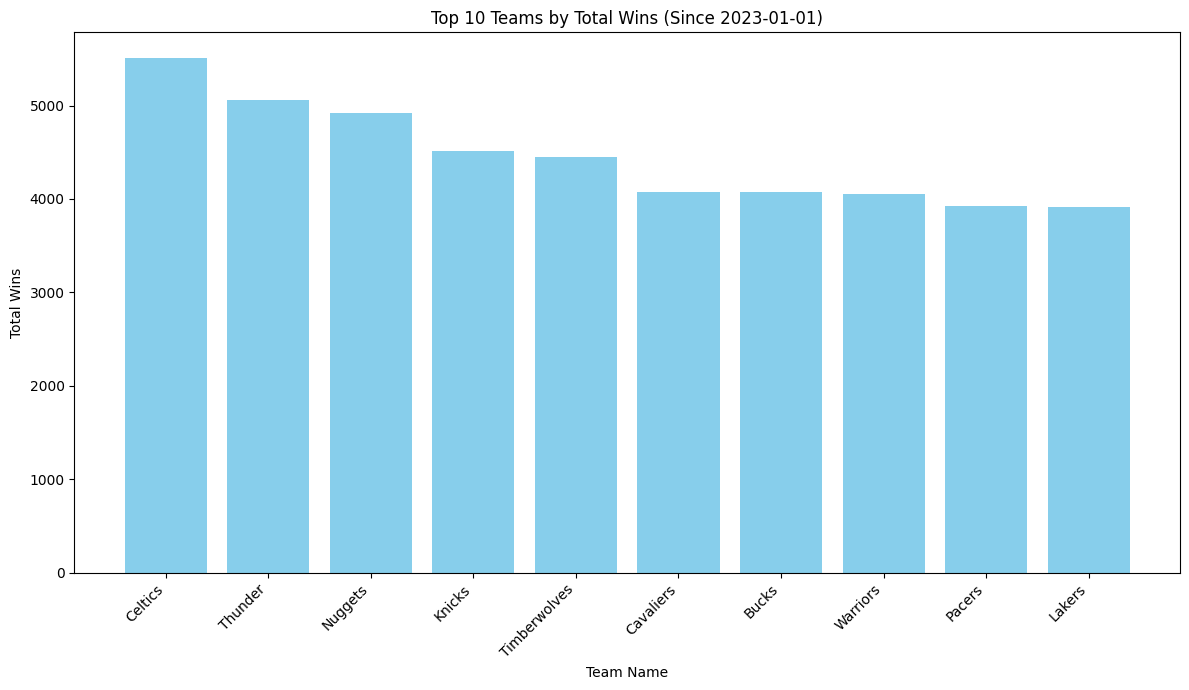

In [55]:
#Task 20: Create a bar chart showing the top 10 teams by total number of wins (home + away) since 2023-01-01.
import matplotlib.pyplot as plt

away_wins_renamed = away_wins.rename(columns={'awayteamName': 'hometeamName'})
total_wins = pd.merge(home_wins, away_wins_renamed, on='hometeamName', how='outer')
total_wins = total_wins.fillna(0)
total_wins['totalWins'] = total_wins['homeWins'] + total_wins['awayWins']


top_10_teams = total_wins.sort_values(by='totalWins', ascending=False).head(10)

plt.figure(figsize=(12, 7))
plt.bar(top_10_teams['hometeamName'], top_10_teams['totalWins'], color='skyblue')
plt.xlabel('Team Name')
plt.ylabel('Total Wins')
plt.title('Top 10 Teams by Total Wins (Since 2023-01-01)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

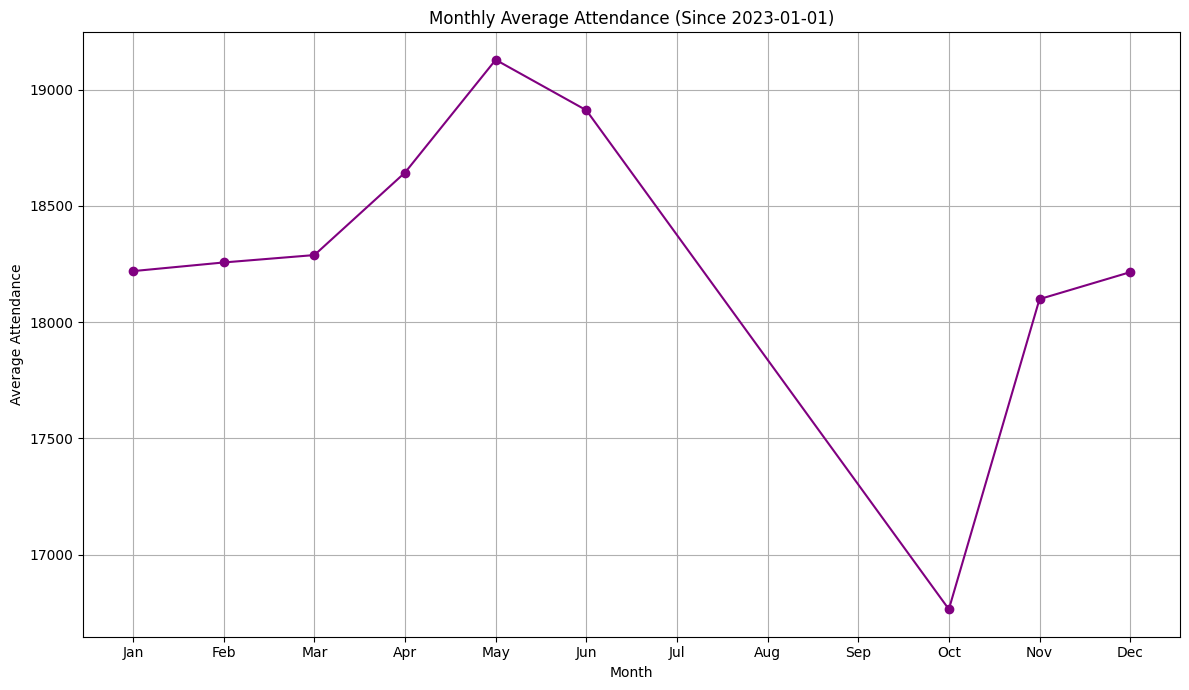

In [58]:
#Task 21: Create a line plot showing the average attendance over time (grouped by month)
#for all games since 2023-01-01. The x-axis should show months and the y-axis should show average attendance.
games['gameDate'] = pd.to_datetime(games['gameDate'], errors='coerce', utc=True, format='ISO8601')
games['month'] = games['gameDate'].dt.month
monthly_avg_attendance = games.groupby('month')['attendance'].mean().reset_index()

plt.figure(figsize=(12, 7))
plt.plot(monthly_avg_attendance['month'], monthly_avg_attendance['attendance'], marker='o', linestyle='-', color='purple')
plt.xlabel('Month')
plt.ylabel('Average Attendance')
plt.title('Monthly Average Attendance (Since 2023-01-01)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.tight_layout()
plt.show()

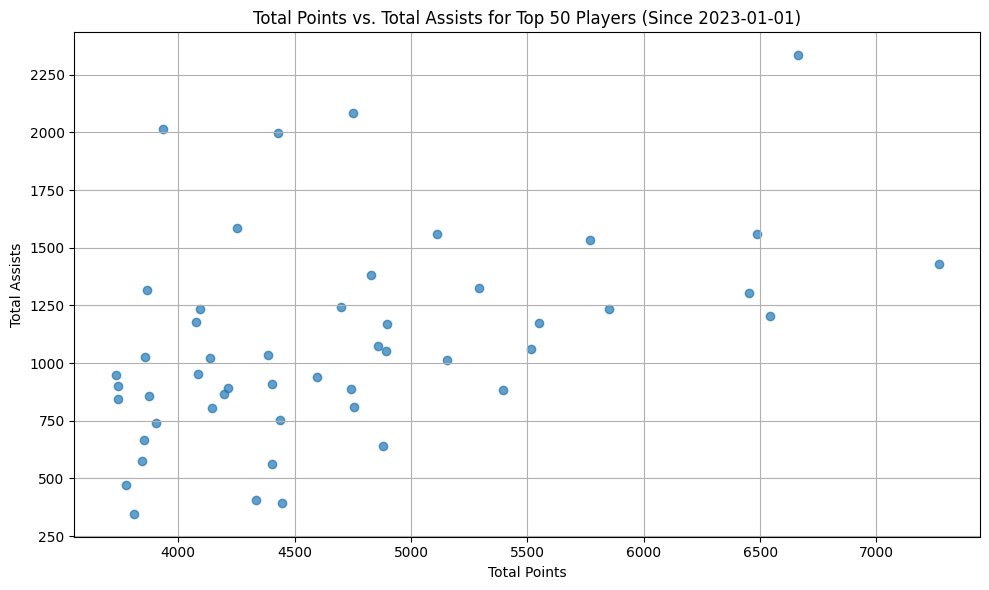

In [62]:
#Task 22: Create a scatter plot showing the relationship
#between total points (x-axis) and total assists (y-axis) for the top 50 players ranked by total points since 2023-01-01
player_summary = player_stats.groupby(['personId', 'firstName', 'lastName']).agg(
    total_points=('points', 'sum'),
    total_assists=('assists', 'sum')
).reset_index()

top_50_players = player_summary.sort_values(by='total_points', ascending=False).head(50)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(top_50_players['total_points'], top_50_players['total_assists'], alpha=0.7)
plt.title('Total Points vs. Total Assists for Top 50 Players (Since 2023-01-01)')
plt.xlabel('Total Points')
plt.ylabel('Total Assists')
plt.grid(True)
plt.tight_layout()
plt.show()

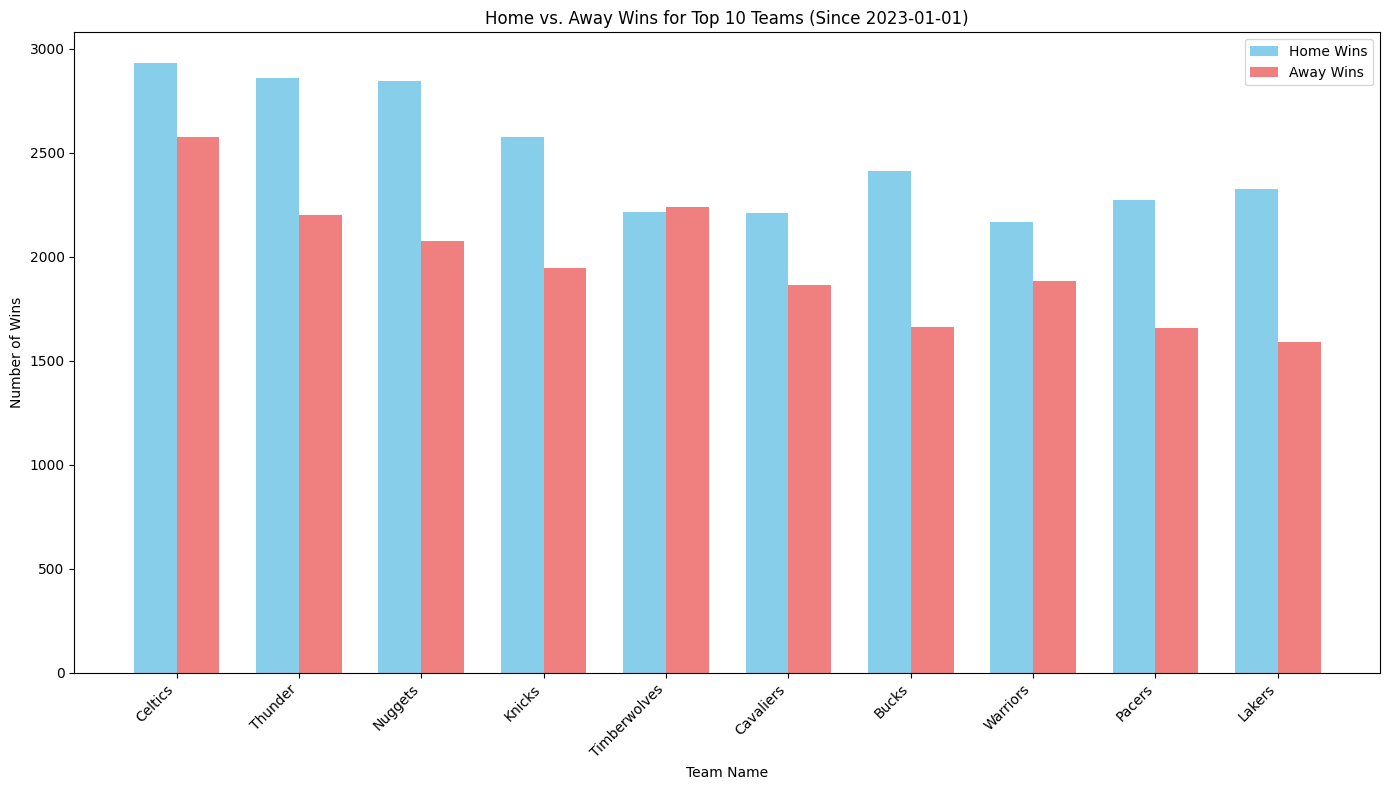

In [64]:
#Task 23: Create side-by-side bar charts comparing home wins vs away wins for the top 10 teams
#ranked by total wins. Each team should have two bars showing their home win count and away win count.
# Set the width for the bars
bar_width = 0.35

# Create an array for the x-axis positions of the teams
x = np.arange(len(top_10_teams))

# Create a figure and an axes object for the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot the home wins as bars, offsetting them slightly
ax.bar(x - bar_width/2, top_10_teams['homeWins'], bar_width, label='Home Wins', color='skyblue')

# Plot the away wins as bars, offsetting them in the opposite direction
ax.bar(x + bar_width/2, top_10_teams['awayWins'], bar_width, label='Away Wins', color='lightcoral')

# Set the labels for the x-axis and y-axis
ax.set_xlabel('Team Name')
ax.set_ylabel('Number of Wins')

# Set the title of the chart
ax.set_title('Home vs. Away Wins for Top 10 Teams (Since 2023-01-01)')

# Set the x-axis ticks to be the team names
ax.set_xticks(x)
ax.set_xticklabels(top_10_teams['hometeamName'], rotation=45, ha='right')

# Add a legend to differentiate between home and away wins
ax.legend()

# Use plt.tight_layout() to adjust plot parameters for a tight layout
plt.tight_layout()

# Display the plot
plt.show()

/tmp/ipython-input-2141154362.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hometeamName', y='homeScore', data=top_home_games_data, palette='viridis')


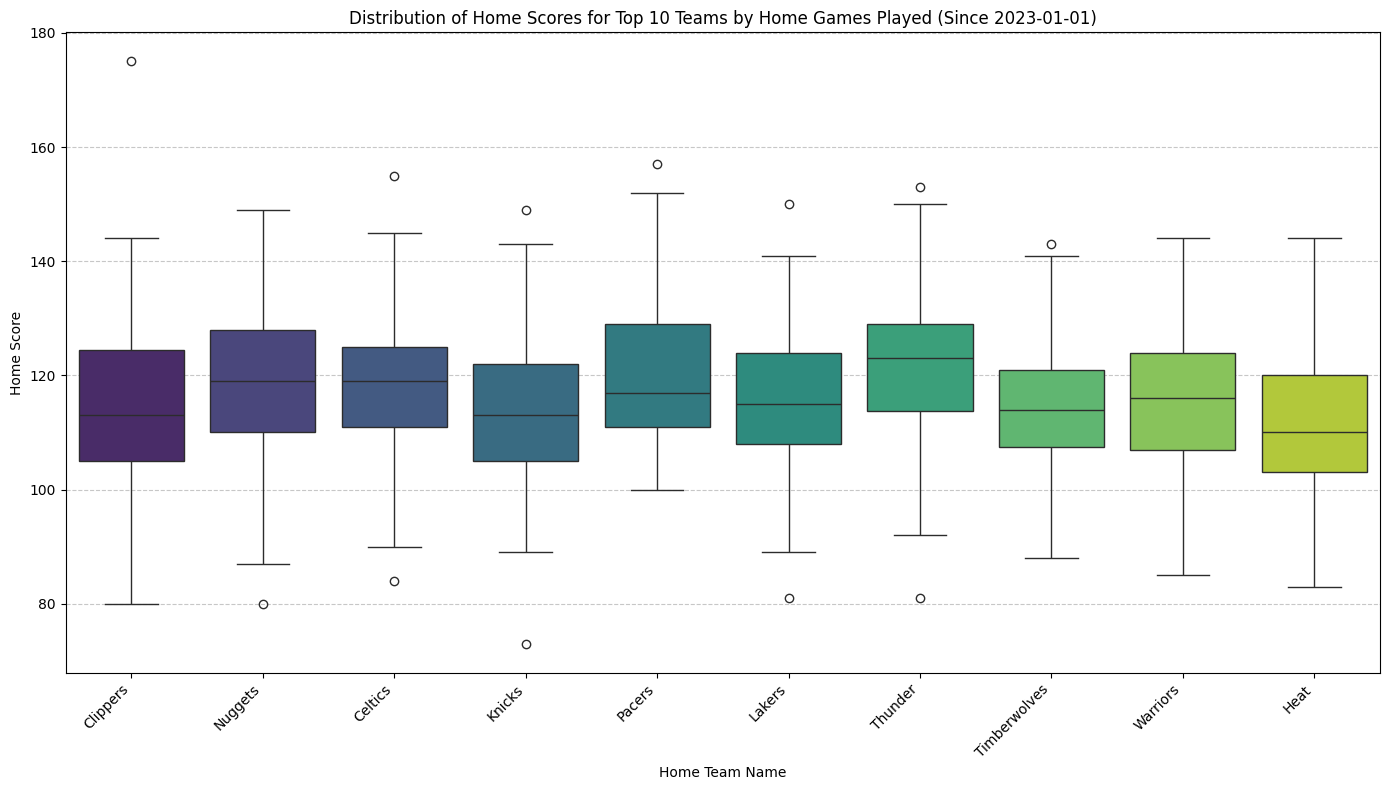

In [72]:
#Task 24: Create a box plot showing the distribution of home scores for the top 10 teams by total number of home games played since 2023-01-01.
#Each team should have one box showing their home score distribution across all their home games.
home_games_count = games.groupby('hometeamName')['gameId'].count().reset_index(name='totalHomeGames')
top_10_home_teams_by_games = home_games_count.sort_values(by='totalHomeGames', ascending=False).head(10)

top_10_team_names = top_10_home_teams_by_games['hometeamName'].tolist()


top_home_games_data = games[games['hometeamName'].isin(top_10_team_names)]

plt.figure(figsize=(14, 8))
sns.boxplot(x='hometeamName', y='homeScore', data=top_home_games_data, palette='viridis')
plt.xlabel('Home Team Name')
plt.ylabel('Home Score')
plt.title('Distribution of Home Scores for Top 10 Teams by Home Games Played (Since 2023-01-01)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


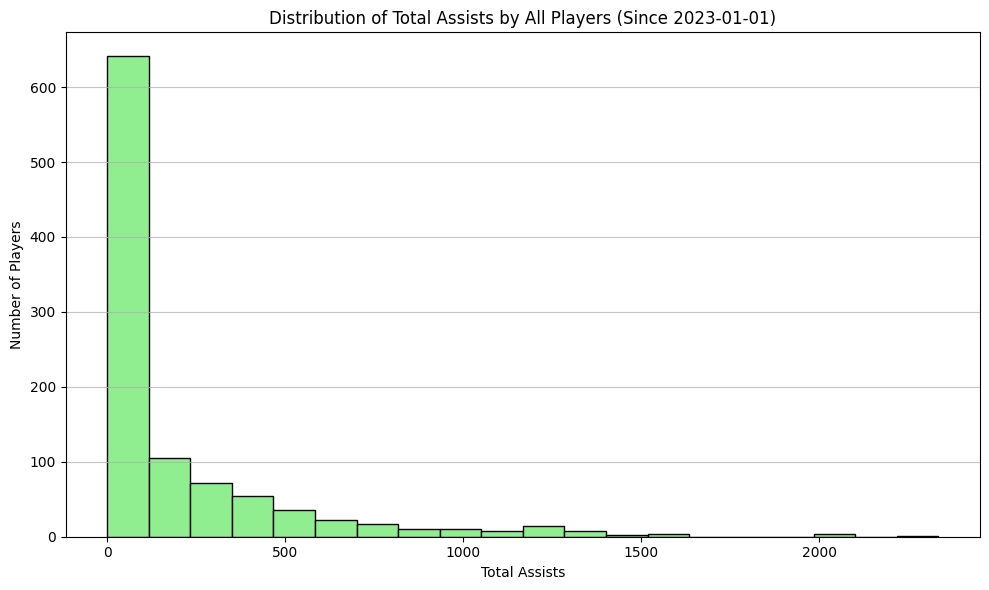

In [68]:
#Task 25: Create a histogram showing the distribution of total assists made by all players
#since 2023-01-01. Use appropriate bins to show the frequency distribution.

plt.figure(figsize=(10, 6))
plt.hist(player_summary['total_assists'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Distribution of Total Assists by All Players (Since 2023-01-01)')
plt.xlabel('Total Assists')
plt.ylabel('Number of Players')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

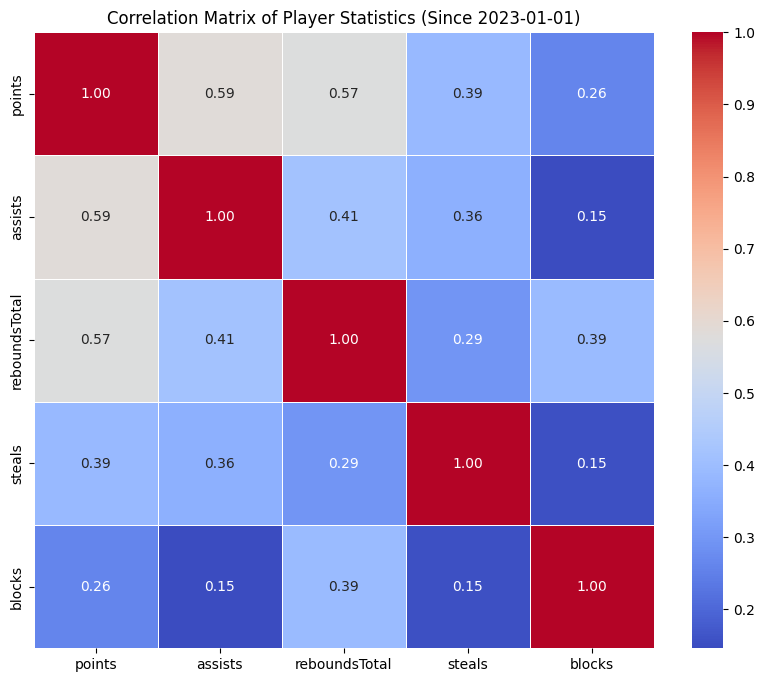

In [71]:
#Task 26: Create a heatmap showing the correlation matrix between five player statistics:
#points, assists, rebounds, steals, and blocks for all players since 2023-01-01. The heatmap
#should display correlation coefficients between each pair of statistics.
import seaborn as sns
player_stats_for_correlation = player_stats[['points', 'assists', 'reboundsTotal', 'steals', 'blocks']]

correlation_matrix = player_stats_for_correlation.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Player Statistics (Since 2023-01-01)')
plt.show()


Task 27: I believe Giannis Antetokounmpo will be the MVP for 2025 for three reasons:
1. He is the 5th highest scorer in the NBA with 64.
2. He has the 9th highest assists in the NBA with 20.
3. He was a previous two-time mvp and the most noteworthy player on the Bucks.